## **Gradient Descent Animation (m and b)**

### **Import Libraries**

In [32]:
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt

### **Enable Animation**

In [33]:
%matplotlib inline
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
from IPython.display import HTML


### **Generate Dataset**

In [34]:
X,y = make_regression(
    n_samples=100,
    n_features=1,
    n_informative=1,
    n_targets=1,
    noise=20,
    random_state=13
)

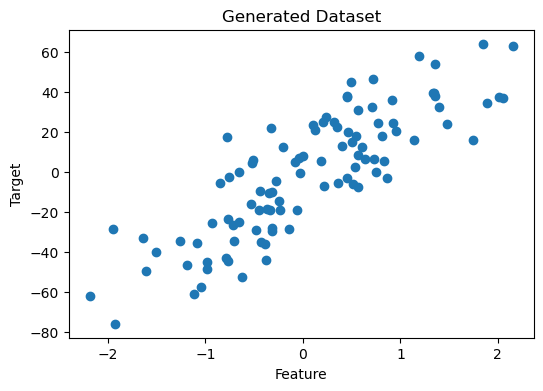

In [35]:
plt.figure(figsize=(6,4))
plt.scatter(X,y)
plt.title("Generated Dataset")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.show()

### **Initialize Parameters**

In [36]:
b = -200
m = 200
lr = 0.001

all_b = []
all_m = []
all_cost = []

epochs = 30

- Initial slope and intercept are intentionally far from optimal values.

### **Gradient Descent**

In [37]:
for i in range(epochs):
    
    slope_b = 0
    slope_m = 0
    cost = 0
    
    for j in range(X.shape[0]):
        
        x_val = X[j][0]
        
        slope_b = slope_b - 2*(y[j] - (m * x_val) - b)
        
        slope_m = slope_m - 2*(y[j] - (m * x_val) - b)*x_val
        
        cost = cost + (y[j] - m * x_val - b) ** 2

    b = b - (lr * slope_b)
    m = m - (lr * slope_m)

    all_b.append(b)
    all_m.append(m)
    all_cost.append(cost)

- Gradient descent iteratively updates parameters and tracks cost.

## **Animate Regression Line Movement**

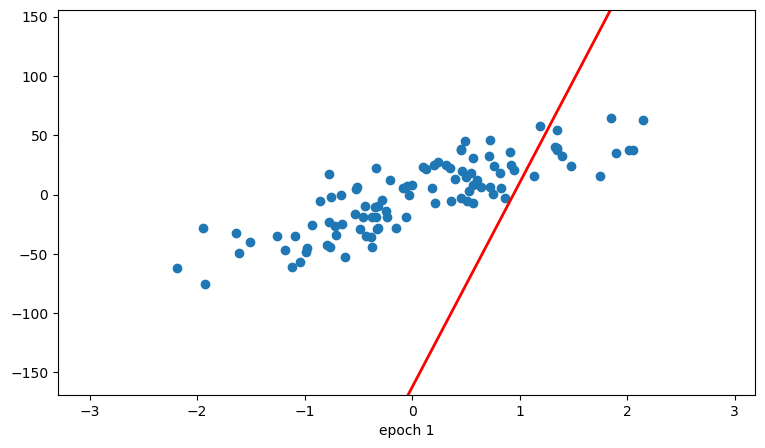

In [38]:
fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3,3,0.1)

ax.scatter(X,y)

line, = ax.plot(x_i,x_i*50-4,'r-',linewidth=2)

def update(i):

    label = 'epoch {0}'.format(i+1)

    line.set_ydata(x_i*all_m[i] + all_b[i])

    ax.set_xlabel(label)

anim = FuncAnimation(fig,update,frames=epochs,interval=500)

HTML(anim.to_jshtml())

- Shows how the regression line moves toward the optimal fit.

### **Animate Cost Function**

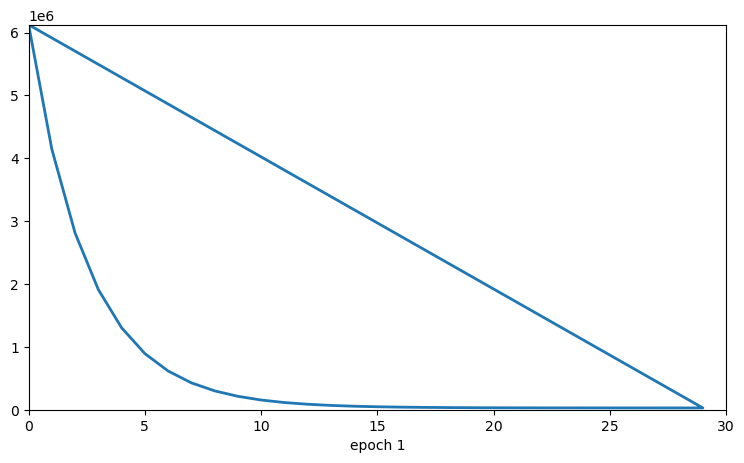

In [39]:
num_epochs = list(range(epochs))

fig = plt.figure(figsize=(9,5))

axis = plt.axes(xlim=(0,epochs), ylim=(0,max(all_cost)))

line, = axis.plot([],[],lw=2)

xdata = []
ydata = []

def animate(i):

    label = 'epoch {0}'.format(i+1)

    xdata.append(num_epochs[i])
    ydata.append(all_cost[i])

    line.set_data(xdata,ydata)

    axis.set_xlabel(label)

    return line,

anim = animation.FuncAnimation(fig,animate,frames=epochs,repeat=False,interval=500)

HTML(anim.to_jshtml())

- Cost decreases as Gradient Descent converges.

## **Intercept Animation**

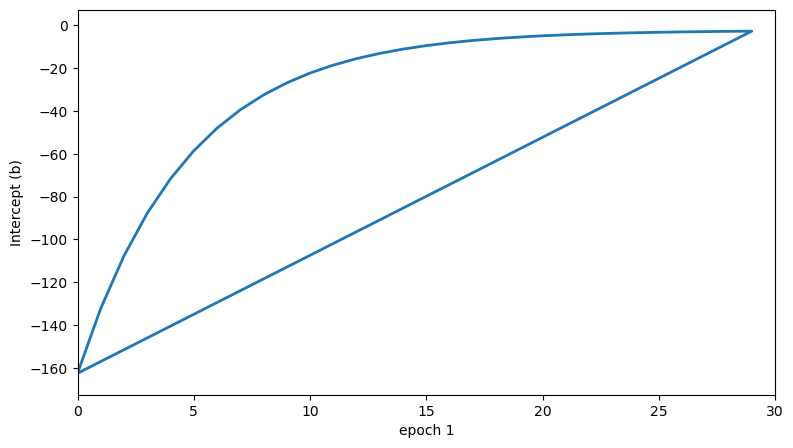

In [40]:
num_epochs = list(range(epochs))

fig = plt.figure(figsize=(9,5))

axis = plt.axes(
    xlim=(0,epochs),
    ylim=(min(all_b)-10, max(all_b)+10)
)

line, = axis.plot([],[],lw=2)

xdata = []
ydata = []

def animate(i):

    label = 'epoch {0}'.format(i+1)

    xdata.append(num_epochs[i])
    ydata.append(all_b[i])

    line.set_data(xdata,ydata)

    axis.set_xlabel(label)
    axis.set_ylabel("Intercept (b)")

    return line,

anim = animation.FuncAnimation(fig,animate,frames=epochs,repeat=False,interval=500)

HTML(anim.to_jshtml())

### **Slope Animation**

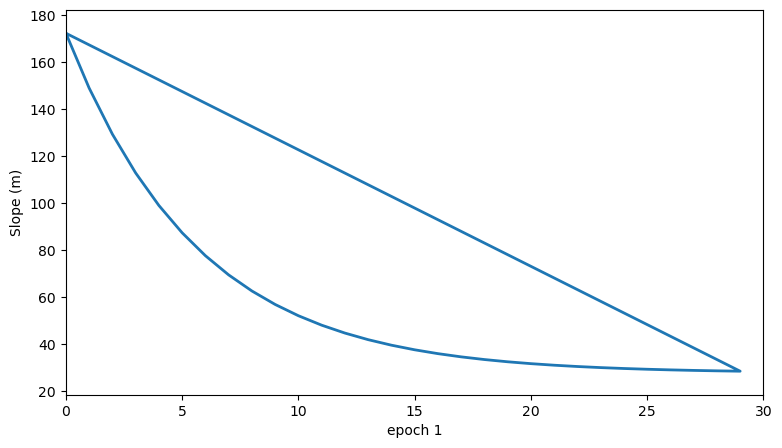

In [41]:
num_epochs = list(range(epochs))

fig = plt.figure(figsize=(9,5))

axis = plt.axes(
    xlim=(0,epochs),
    ylim=(min(all_m)-10, max(all_m)+10)
)

line, = axis.plot([],[],lw=2)

xdata = []
ydata = []

def animate(i):

    label = 'epoch {0}'.format(i+1)

    xdata.append(num_epochs[i])
    ydata.append(all_m[i])

    line.set_data(xdata,ydata)

    axis.set_xlabel(label)
    axis.set_ylabel("Slope (m)")

    return line,

anim = animation.FuncAnimation(fig,animate,frames=epochs,repeat=False,interval=500)

HTML(anim.to_jshtml())